# Image / mask pair viewer

Finds every `images/` + `masks/` pair under the data folder and plots image, colored mask, and overlay.
Class colors come from `manifest.json` when present, otherwise a default palette.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch
from PIL import Image

Image.MAX_IMAGE_PIXELS = None

# Root of the dataset(s). Point this at whichever folder you want to browse.
DATA_ROOT = Path("D_A___e_rec20260221_135217_petiole22_20260717_175256")

OVERLAY_ALPHA = 0.45  # mask opacity in the overlay panel
MAX_PAIRS = None      # e.g. 5 to only plot the first few
IMAGE_EXTS = {".png", ".tif", ".tiff", ".jpg", ".jpeg"}

In [2]:
DEFAULT_PALETTE = [
    "#3c97d7", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]


def load_class_info(root: Path) -> dict:
    """Return {class_id: (label, hex_color)} from manifest.json / classes.json."""
    info = {}

    manifest = next(root.rglob("manifest.json"), None)
    if manifest is not None:
        for i, cls in enumerate(json.loads(manifest.read_text()).get("classes", [])):
            cid = int(cls["classId"])
            info[cid] = (
                cls.get("label", f"class {cid}"),
                cls.get("color") or DEFAULT_PALETTE[i % len(DEFAULT_PALETTE)],
            )

    classes = next(root.rglob("classes.json"), None)
    if classes is not None:
        for i, (k, label) in enumerate(json.loads(classes.read_text()).items()):
            cid = int(k)
            if cid == 0 or cid in info:
                continue
            info[cid] = (label, DEFAULT_PALETTE[i % len(DEFAULT_PALETTE)])

    return info


def find_pairs(root: Path) -> list:
    """Match files in any images/ dir to same-named files in the sibling masks/ dir."""
    pairs = []
    for img_dir in sorted(p for p in root.rglob("images") if p.is_dir()):
        mask_dir = img_dir.parent / "masks"
        if not mask_dir.is_dir():
            continue
        masks = {p.stem: p for p in mask_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS}
        for img in sorted(p for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS):
            if img.stem in masks:
                pairs.append((img, masks[img.stem]))
    return pairs


CLASS_INFO = load_class_info(DATA_ROOT)
PAIRS = find_pairs(DATA_ROOT)

print(f"{len(PAIRS)} image/mask pairs found")
for cid, (label, color) in sorted(CLASS_INFO.items()):
    print(f"  {cid}: {label:<12} {color}")

8 image/mask pairs found
  1: air          #3c97d7
  2: xylem        #ff7f0e
  3: cortex       #2ca02c
  4: pith         #d62728
  5: phloem       #9467bd


In [3]:
def load_mask(path: Path) -> np.ndarray:
    """Read a label mask as a 2-D integer array (RGB masks collapse to channel 0)."""
    mask = np.asarray(Image.open(path))
    return mask[..., 0] if mask.ndim == 3 else mask


def class_name(i: int) -> str:
    if i == 0:
        return "background/unlabeled"
    return CLASS_INFO.get(int(i), (f"class {i}", None))[0]


def build_cmap(class_info: dict, n_ids: int) -> ListedColormap:
    """Colormap where index == class id; id 0 (background) is black / masked out."""
    colors = [(0.0, 0.0, 0.0)]
    for cid in range(1, max(n_ids, 2)):
        hex_color = class_info.get(cid, (None, DEFAULT_PALETTE[(cid - 1) % len(DEFAULT_PALETTE)]))[1]
        colors.append(to_rgb(hex_color))
    return ListedColormap(colors)


def plot_pair(img_path: Path, mask_path: Path, alpha: float = OVERLAY_ALPHA) -> None:
    image = np.asarray(Image.open(img_path))
    mask = load_mask(mask_path)

    present = [int(v) for v in np.unique(mask) if v != 0]
    n_ids = max([*present, *CLASS_INFO, 1]) + 1
    cmap = build_cmap(CLASS_INFO, n_ids)
    masked = np.ma.masked_where(mask == 0, mask)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.8))
    axes[0].imshow(image, cmap=None if image.ndim == 3 else "gray")
    axes[0].set_title("image")

    axes[1].imshow(masked, cmap=cmap, vmin=0, vmax=n_ids - 1, interpolation="nearest")
    axes[1].set_title("mask")

    axes[2].imshow(image, cmap=None if image.ndim == 3 else "gray")
    axes[2].imshow(masked, cmap=cmap, vmin=0, vmax=n_ids - 1, alpha=alpha, interpolation="nearest")
    axes[2].set_title(f"overlay (alpha={alpha})")

    for ax in axes:
        ax.axis("off")

    handles = [Patch(facecolor=cmap(cid), label=class_name(cid)) for cid in present]
    if handles:
        axes[2].legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

    split = img_path.parent.parent.name
    fig.suptitle(f"{split} / {img_path.name}", fontsize=11)
    fig.tight_layout()
    plt.show()

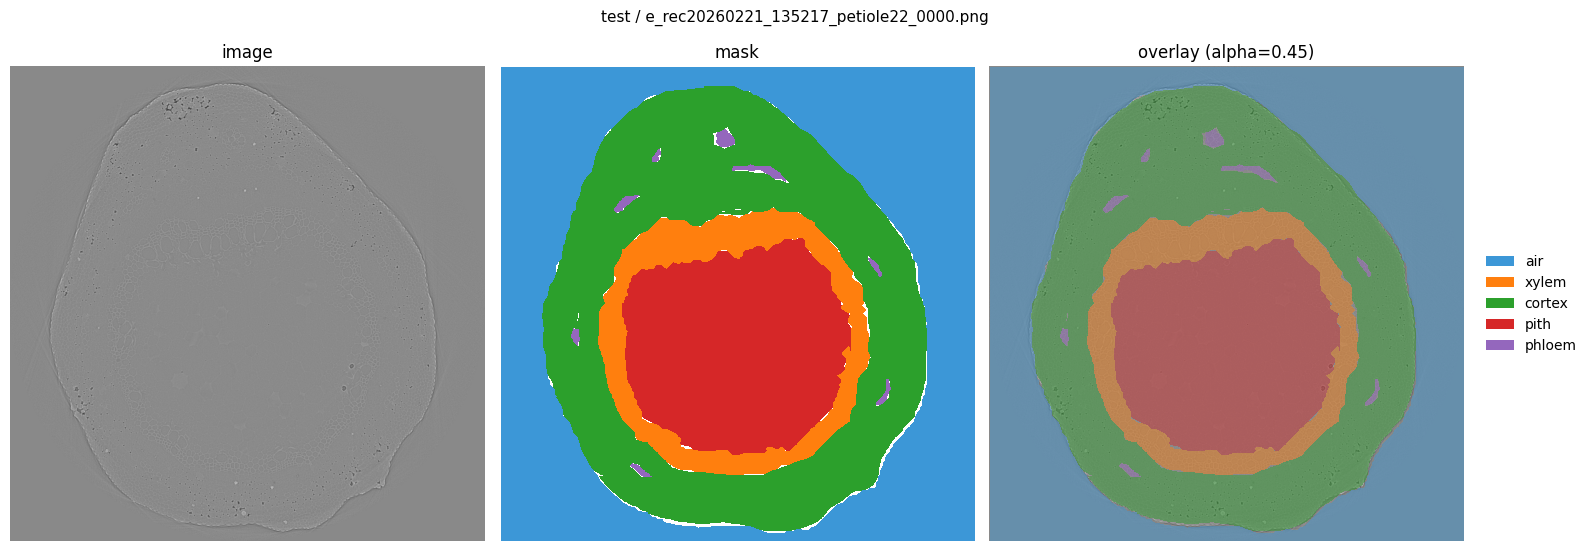

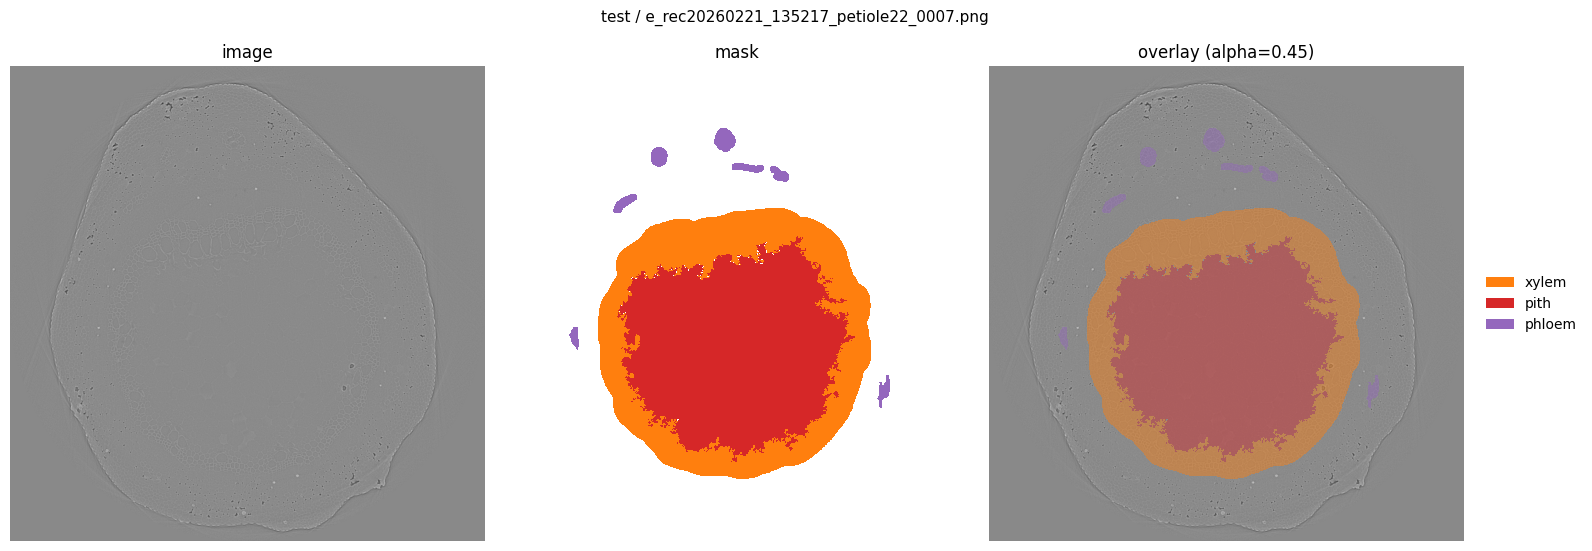

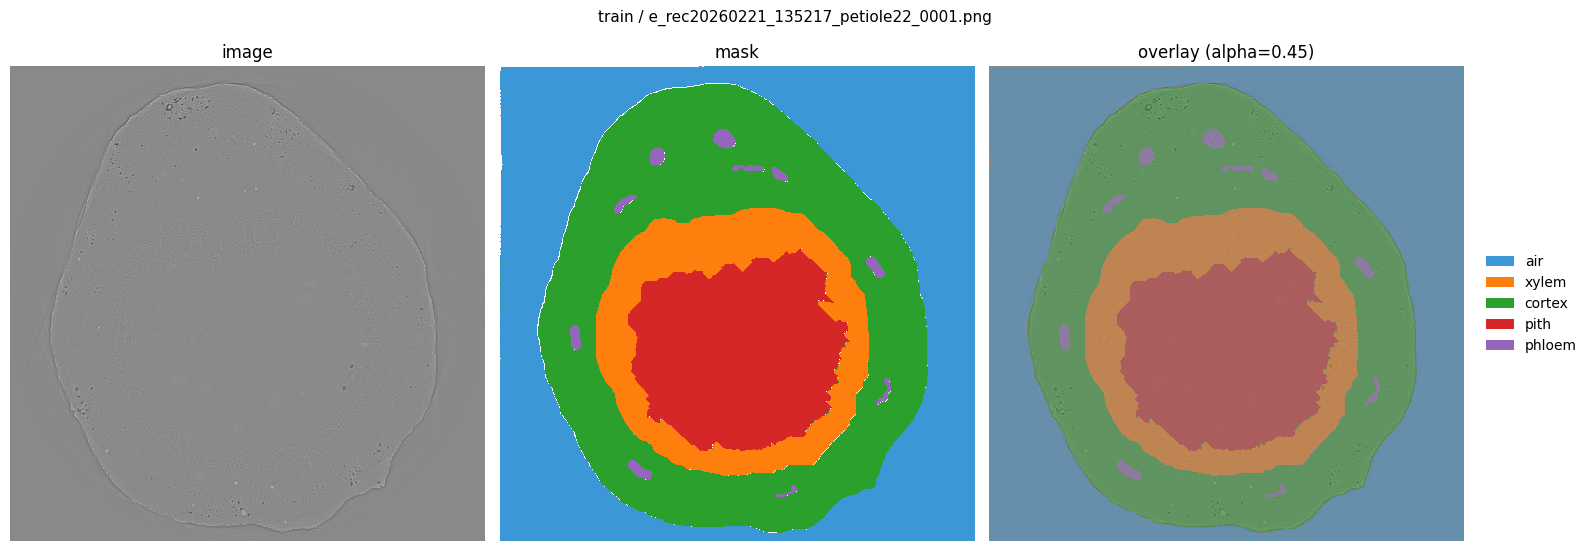

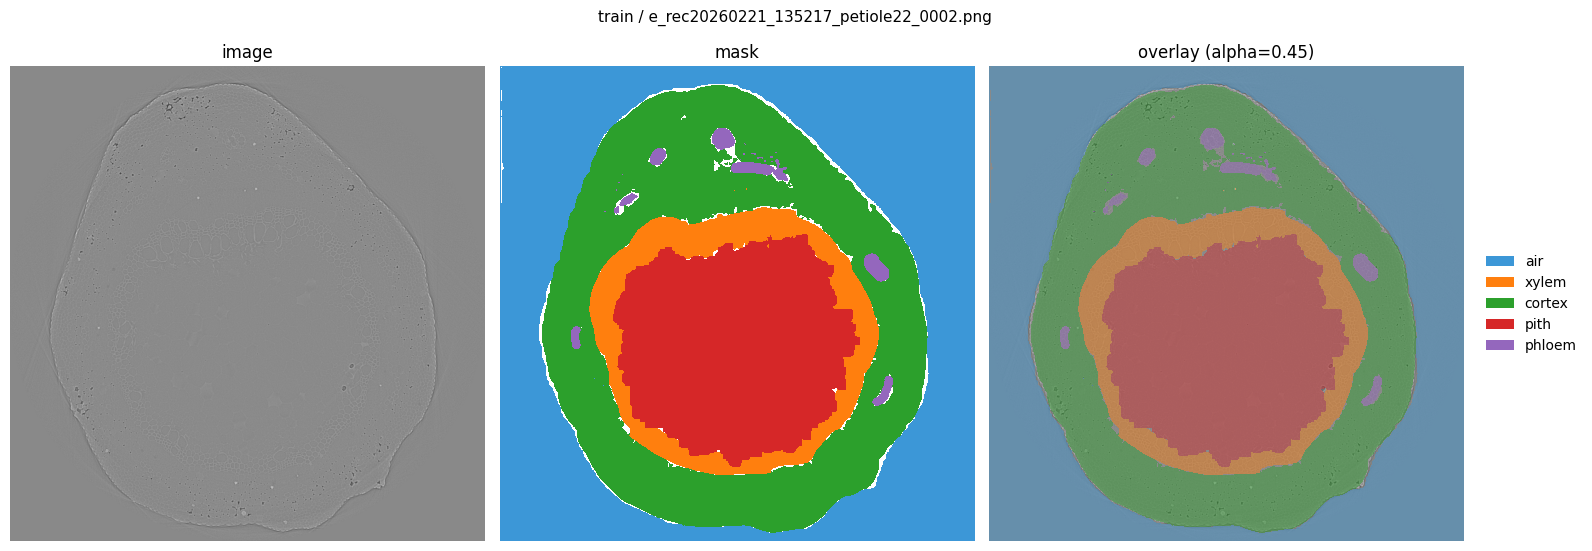

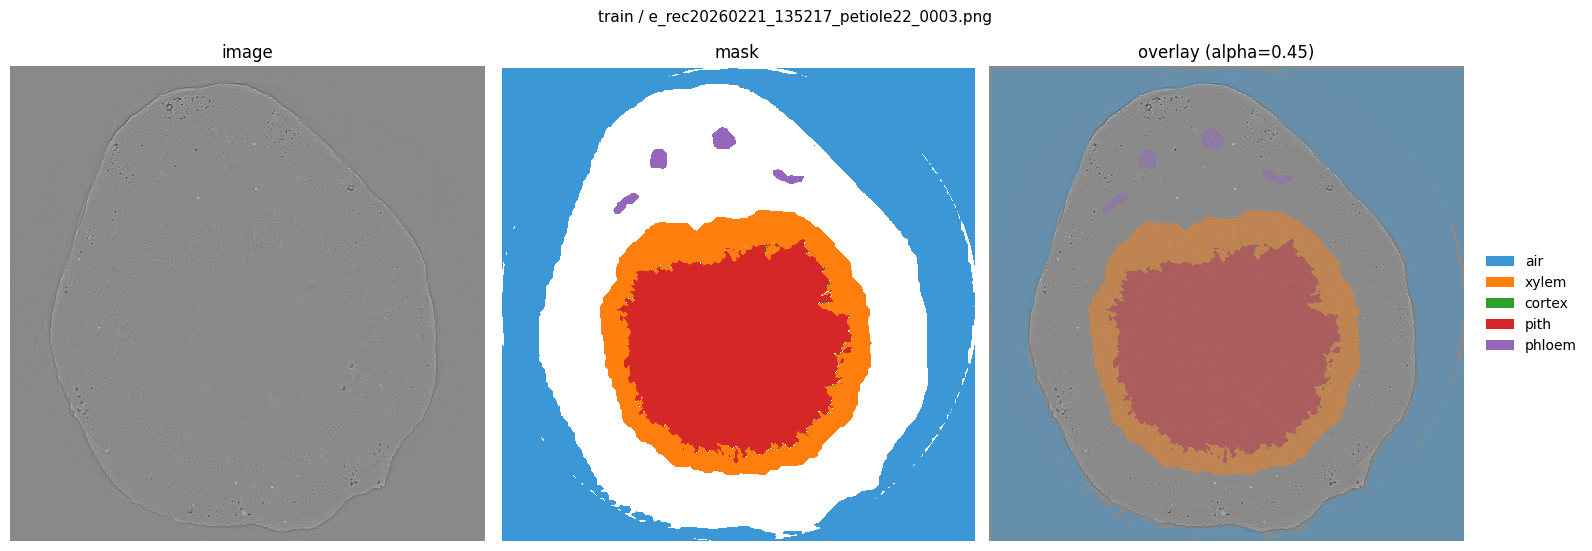

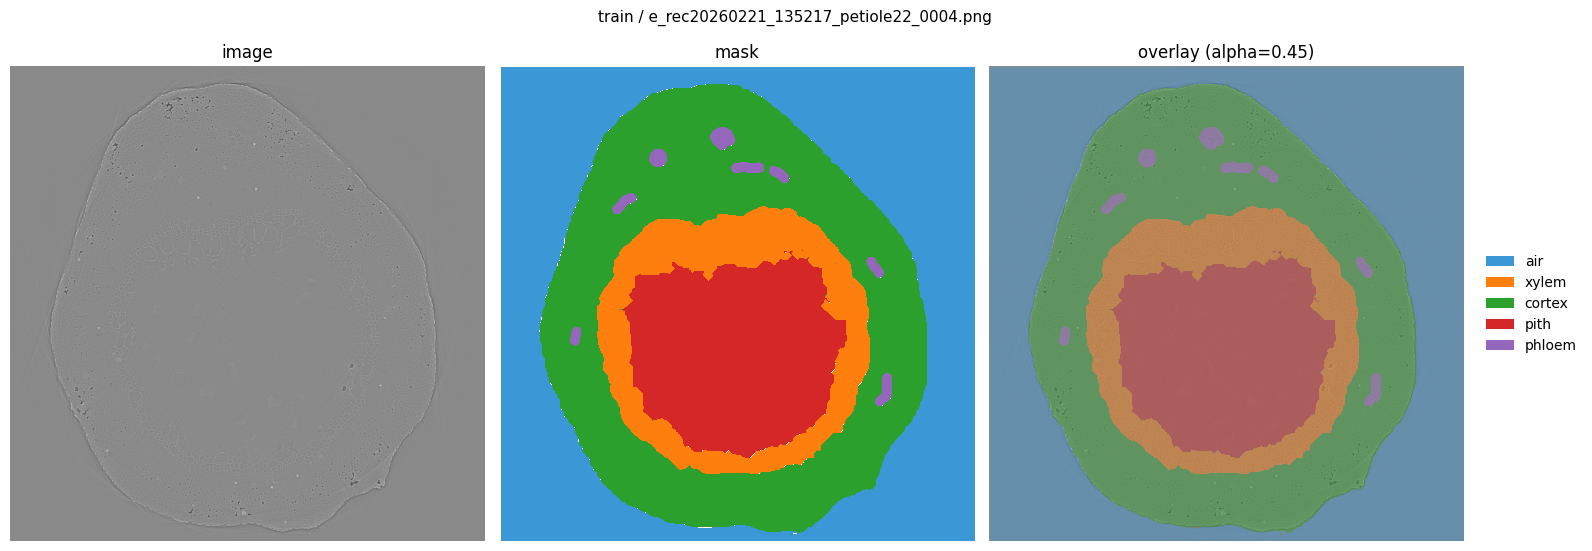

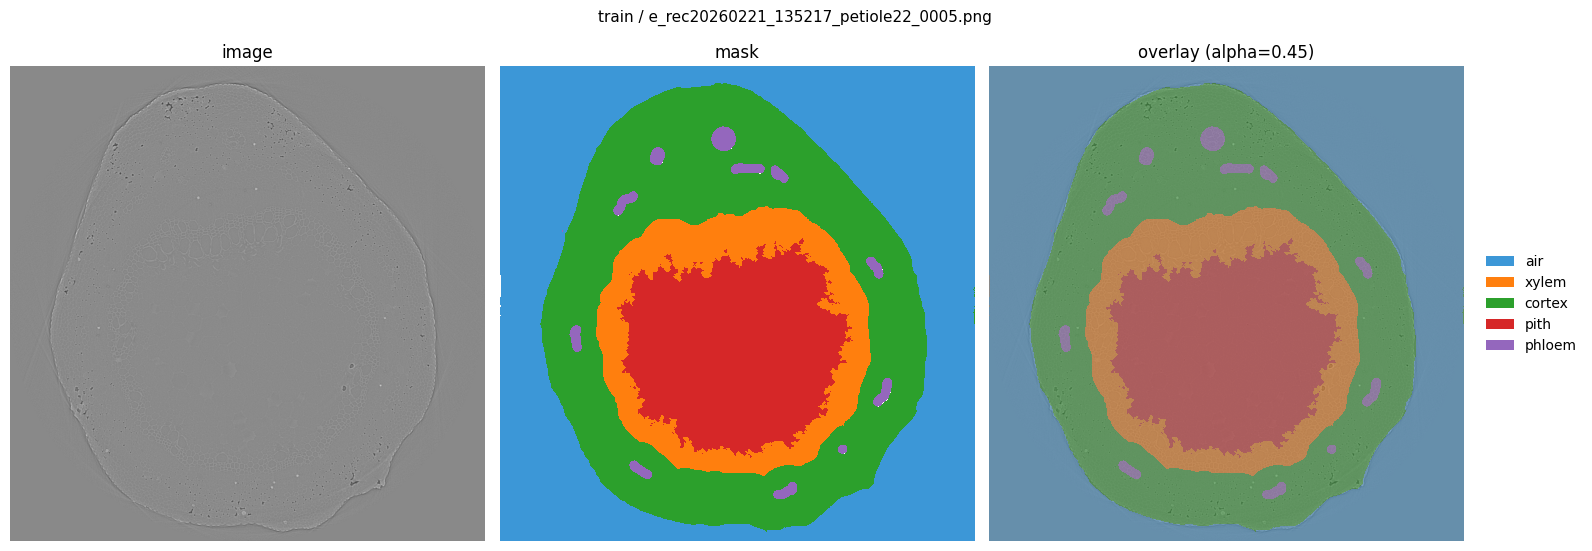

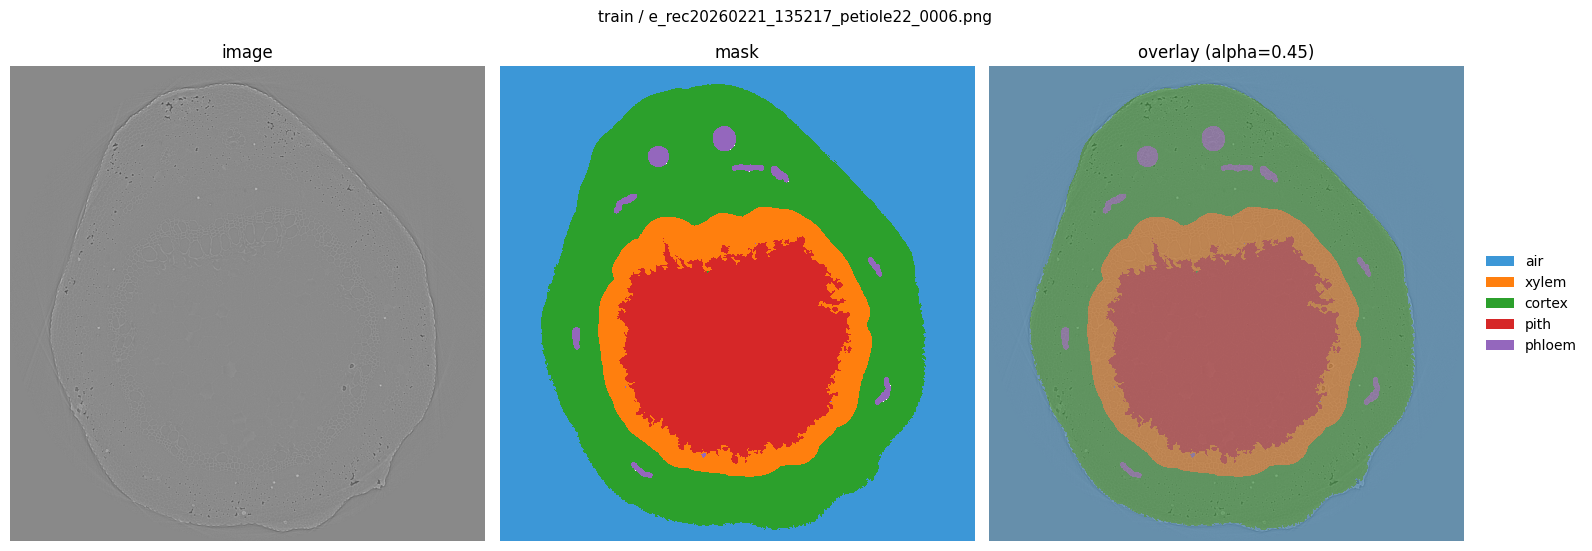

In [4]:
for img_path, mask_path in PAIRS[:MAX_PAIRS]:
    plot_pair(img_path, mask_path)

## Distinct values in each mask

Masks are single-channel `uint8` label maps: **the pixel value *is* the class id**, not a color.

**Unannotated pixels default to `0`** — `"background"` in `classes.json`. There is no separate
"ignore" / "void" value, so a `0` means either genuinely background or simply never painted, and
the two are indistinguishable from the file alone. Watch for masks with a large `0` fraction: those
are partially annotated slices, and training on them teaches the model that real tissue is
background unless you exclude id 0 from the loss.

In [5]:
masks_cache = {}
rows = []

for img_path, mask_path in PAIRS:
    mask = load_mask(mask_path)
    masks_cache[mask_path] = mask

    ids, counts = np.unique(mask, return_counts=True)
    frac = {class_name(int(i)): c / mask.size for i, c in zip(ids, counts)}
    missing = sorted(set(CLASS_INFO) - {int(i) for i in ids})
    rows.append(
        {
            "split": img_path.parent.parent.name,
            "file": img_path.name,
            "dtype": str(mask.dtype),
            "n_distinct": int(len(ids)),
            "values": [int(i) for i in ids],
            "missing_classes": [CLASS_INFO[c][0] for c in missing],
            **frac,
        }
    )

for r in rows:
    print(f"{r['file']}  {r['dtype']}  {r['n_distinct']} distinct values: {r['values']}")
    if r["missing_classes"]:
        print(f"      missing classes: {', '.join(r['missing_classes'])}")

print(f"\nunion of values across dataset: {sorted({v for r in rows for v in r['values']})}")

try:
    import pandas as pd

    display(pd.DataFrame(rows).drop(columns=["values", "missing_classes", "dtype"]).fillna(0).round(4))
except ImportError:
    pass

e_rec20260221_135217_petiole22_0000.png  uint8  6 distinct values: [0, 1, 2, 3, 4, 5]
e_rec20260221_135217_petiole22_0007.png  uint8  4 distinct values: [0, 2, 4, 5]
      missing classes: air, cortex
e_rec20260221_135217_petiole22_0001.png  uint8  6 distinct values: [0, 1, 2, 3, 4, 5]
e_rec20260221_135217_petiole22_0002.png  uint8  6 distinct values: [0, 1, 2, 3, 4, 5]
e_rec20260221_135217_petiole22_0003.png  uint8  6 distinct values: [0, 1, 2, 3, 4, 5]
e_rec20260221_135217_petiole22_0004.png  uint8  6 distinct values: [0, 1, 2, 3, 4, 5]
e_rec20260221_135217_petiole22_0005.png  uint8  6 distinct values: [0, 1, 2, 3, 4, 5]
e_rec20260221_135217_petiole22_0006.png  uint8  6 distinct values: [0, 1, 2, 3, 4, 5]

union of values across dataset: [0, 1, 2, 3, 4, 5]


,split,file,n_distinct,background/unlabeled,air,xylem,cortex,pith,phloem
0,test,e_rec20260221_135217_petiole22_0000.png,6,0.0103,0.4141,0.0849,0.3145,0.1705,0.0057
1,test,e_rec20260221_135217_petiole22_0007.png,4,0.7295,0.0000,0.1072,0.0000,0.1558,0.0074
2,train,e_rec20260221_135217_petiole22_0001.png,6,0.0052,0.4098,0.1147,0.3151,0.1466,0.0086
3,train,e_rec20260221_135217_petiole22_0002.png,6,0.0159,0.4136,0.0791,0.2949,0.1863,0.0103
4,train,e_rec20260221_135217_petiole22_0003.png,6,0.3424,0.3986,0.0927,0.0004,0.1609,0.0050
5,train,e_rec20260221_135217_petiole22_0004.png,6,0.0042,0.4147,0.1082,0.3126,0.1506,0.0097
6,train,e_rec20260221_135217_petiole22_0005.png,6,0.0012,0.4215,0.1043,0.3048,0.1558,0.0123
7,train,e_rec20260221_135217_petiole22_0006.png,6,0.0000,0.4246,0.0928,0.3061,0.1677,0.0087


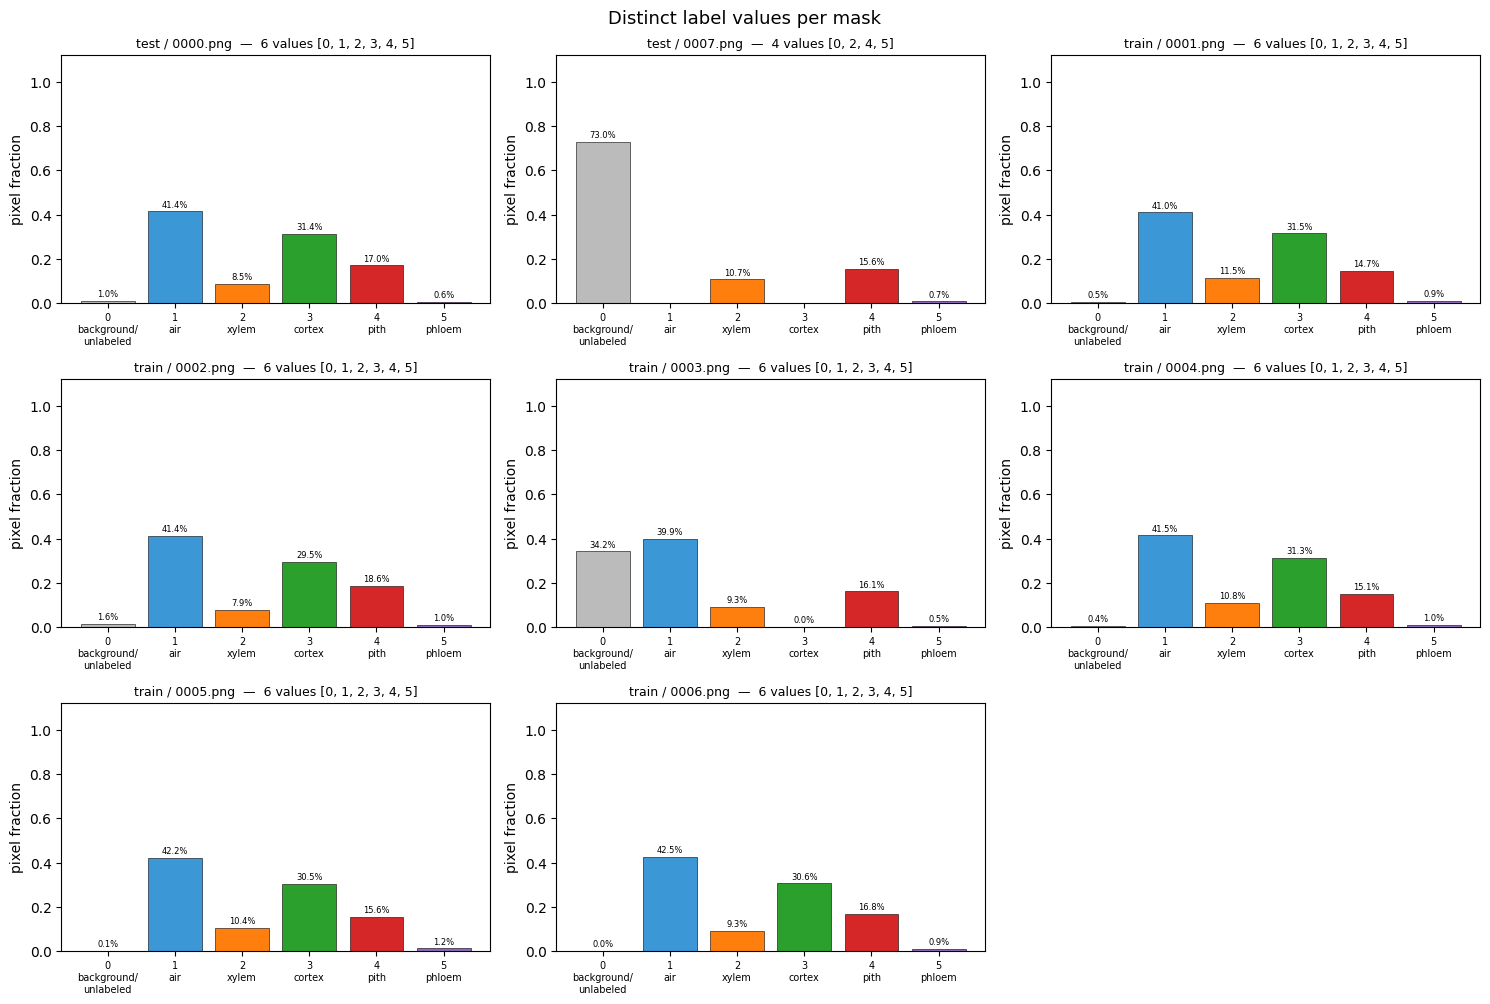

In [6]:
# Value histogram per mask: what fraction of pixels carries each label id.
all_ids = sorted({v for r in rows for v in r["values"]})
hist_cmap = build_cmap(CLASS_INFO, max(all_ids) + 1)
tick_labels = [("0\nbackground/\nunlabeled" if i == 0 else f"{i}\n{class_name(i)}") for i in all_ids]
bar_colors = ["#bbbbbb" if i == 0 else hist_cmap(i) for i in all_ids]

ncols = 3
nrows = -(-len(rows) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.4 * nrows), squeeze=False)

for ax, r in zip(axes.ravel(), rows):
    heights = [r.get(class_name(i), 0.0) for i in all_ids]
    ax.bar(range(len(all_ids)), heights, color=bar_colors, edgecolor="black", linewidth=0.4)
    ax.set_xticks(range(len(all_ids)))
    ax.set_xticklabels(tick_labels, fontsize=7)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("pixel fraction")
    ax.set_title(f"{r['split']} / {r['file'][-8:]}  —  {r['n_distinct']} values {r['values']}", fontsize=9)
    for x, h in enumerate(heights):
        if h:
            ax.text(x, h + 0.02, f"{h:.1%}", ha="center", fontsize=6)

for ax in axes.ravel()[len(rows):]:
    ax.axis("off")

fig.suptitle("Distinct label values per mask", fontsize=13)
fig.tight_layout()
plt.show()

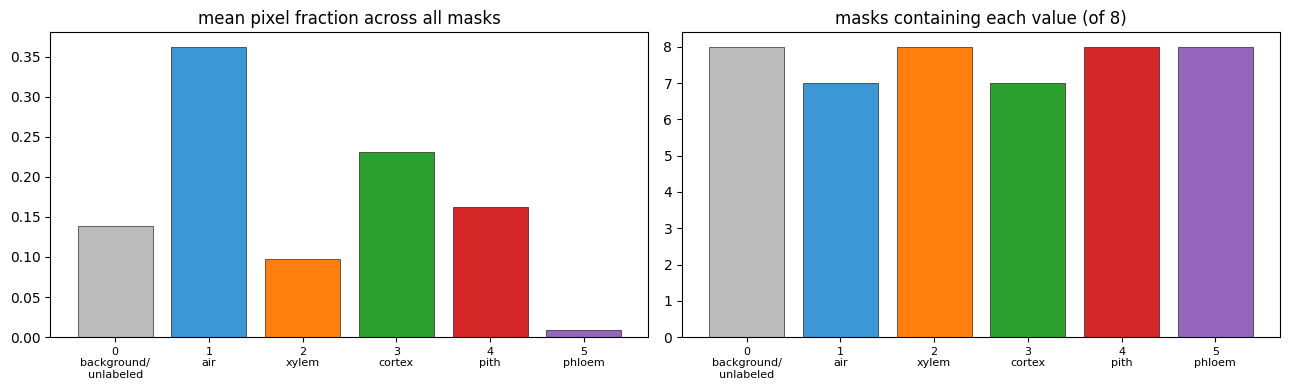

In [7]:
# Dataset-wide view: how often each label id appears, and in how many masks.
totals = {i: sum(r.get(class_name(i), 0.0) for r in rows) / len(rows) for i in all_ids}
n_files = {i: sum(1 for r in rows if i in r["values"]) for i in all_ids}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(len(all_ids)), [totals[i] for i in all_ids], color=bar_colors, edgecolor="black", linewidth=0.4)
axes[0].set_title("mean pixel fraction across all masks")
axes[1].bar(range(len(all_ids)), [n_files[i] for i in all_ids], color=bar_colors, edgecolor="black", linewidth=0.4)
axes[1].set_title(f"masks containing each value (of {len(rows)})")
for ax in axes:
    ax.set_xticks(range(len(all_ids)))
    ax.set_xticklabels(tick_labels, fontsize=8)
fig.tight_layout()
plt.show()

### Where are the unannotated (value 0) pixels?

Magenta = pixels left at the default value `0`. If magenta covers actual tissue rather than the
surrounding air, that slice is incompletely annotated.

2 of 8 masks are more than 5% value-0


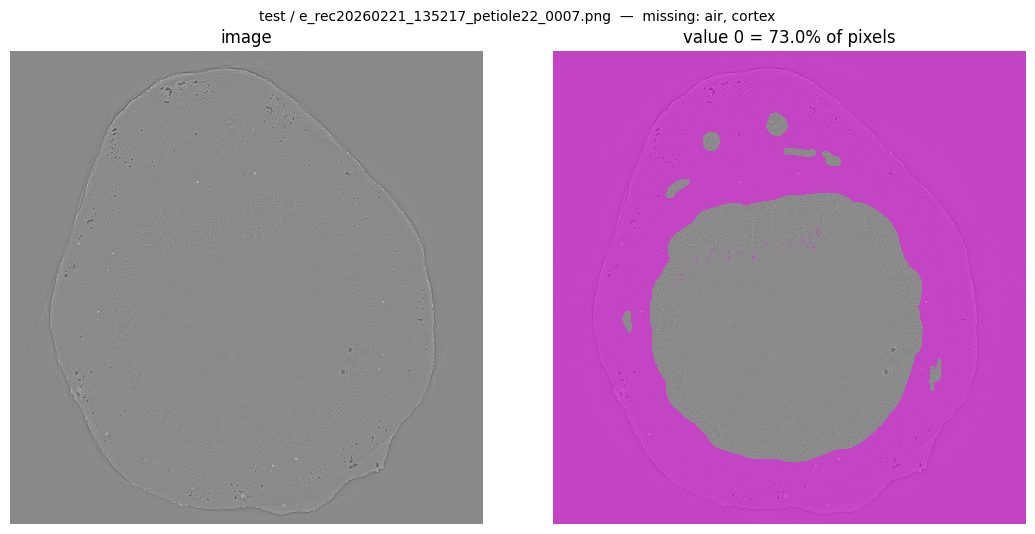

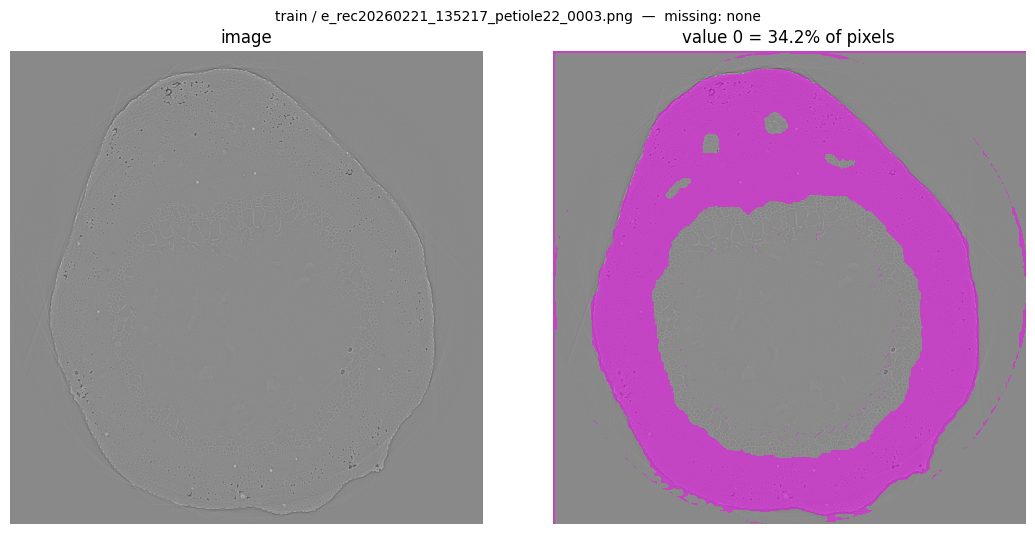

In [8]:
ZERO_WARN_FRAC = 0.05  # only show masks with more than this fraction left at 0

flagged = [(i, r) for i, r in enumerate(rows) if r.get("background/unlabeled", 0.0) > ZERO_WARN_FRAC]
print(f"{len(flagged)} of {len(rows)} masks are more than {ZERO_WARN_FRAC:.0%} value-0")

for i, r in flagged:
    img_path, mask_path = PAIRS[i]
    mask = masks_cache[mask_path]
    image = np.asarray(Image.open(img_path))
    zeros = np.ma.masked_where(mask != 0, np.ones_like(mask))

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.4))
    axes[0].imshow(image, cmap=None if image.ndim == 3 else "gray")
    axes[0].set_title("image")
    axes[1].imshow(image, cmap=None if image.ndim == 3 else "gray")
    axes[1].imshow(zeros, cmap=ListedColormap(["magenta"]), alpha=0.5, interpolation="nearest")
    axes[1].set_title(f"value 0 = {r['background/unlabeled']:.1%} of pixels")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(
        f"{r['split']} / {r['file']}  —  missing: {', '.join(r['missing_classes']) or 'none'}",
        fontsize=10,
    )
    fig.tight_layout()
    plt.show()